<a href="https://colab.research.google.com/github/rikkycodes/Student-Performance-analysis/blob/main/Student_Result_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("Expanded_data_with_more_features.csv")
print(df.head())

   Unnamed: 0  Gender EthnicGroup          ParentEduc     LunchType TestPrep  \
0           0  female         NaN   bachelor's degree      standard     none   
1           1  female     group C        some college      standard      NaN   
2           2  female     group B     master's degree      standard     none   
3           3    male     group A  associate's degree  free/reduced     none   
4           4    male     group C        some college      standard     none   

  ParentMaritalStatus PracticeSport IsFirstChild  NrSiblings TransportMeans  \
0             married     regularly          yes         3.0     school_bus   
1             married     sometimes          yes         0.0            NaN   
2              single     sometimes          yes         4.0     school_bus   
3             married         never           no         1.0            NaN   
4             married     sometimes          yes         0.0     school_bus   

  WklyStudyHours  MathScore  ReadingScore  W

In [ ]:
df.describe()

,Unnamed: 0,NrSiblings,MathScore,ReadingScore,WritingScore
count,30641.000000,29069.000000,30641.000000,30641.000000,30641.000000
mean,499.556607,2.145894,66.558402,69.377533,68.418622
std,288.747894,1.458242,15.361616,14.758952,15.443525
min,0.000000,0.000000,0.000000,10.000000,4.000000
25%,249.000000,1.000000,56.000000,59.000000,58.000000
50%,500.000000,2.000000,67.000000,70.000000,69.000000
75%,750.000000,3.000000,78.000000,80.000000,79.000000
max,999.000000,7.000000,100.000000,100.000000,100.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30641 entries, 0 to 30640
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           30641 non-null  int64  
 1   Gender               30641 non-null  object 
 2   EthnicGroup          28801 non-null  object 
 3   ParentEduc           28796 non-null  object 
 4   LunchType            30641 non-null  object 
 5   TestPrep             28811 non-null  object 
 6   ParentMaritalStatus  29451 non-null  object 
 7   PracticeSport        30010 non-null  object 
 8   IsFirstChild         29737 non-null  object 
 9   NrSiblings           29069 non-null  float64
 10  TransportMeans       27507 non-null  object 
 11  WklyStudyHours       29686 non-null  object 
 12  MathScore            30641 non-null  int64  
 13  ReadingScore         30641 non-null  int64  
 14  WritingScore         30641 non-null  int64  
dtypes: float64(1), int64(4), object(10)


In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
Gender,0
EthnicGroup,1840
ParentEduc,1845
LunchType,0
TestPrep,1830
ParentMaritalStatus,1190
PracticeSport,631
IsFirstChild,904
NrSiblings,1572


In [ ]:
#drop/delete unnamed column
df = df.drop("Unnamed: 0", axis = 1)
print(df.head())

   Gender EthnicGroup          ParentEduc     LunchType TestPrep  \
0  female         NaN   bachelor's degree      standard     none   
1  female     group C        some college      standard      NaN   
2  female     group B     master's degree      standard     none   
3    male     group A  associate's degree  free/reduced     none   
4    male     group C        some college      standard     none   

  ParentMaritalStatus PracticeSport IsFirstChild  NrSiblings TransportMeans  \
0             married     regularly          yes         3.0     school_bus   
1             married     sometimes          yes         0.0            NaN   
2              single     sometimes          yes         4.0     school_bus   
3             married         never           no         1.0            NaN   
4             married     sometimes          yes         0.0     school_bus   

  WklyStudyHours  MathScore  ReadingScore  WritingScore  
0            < 5         71            71            74  


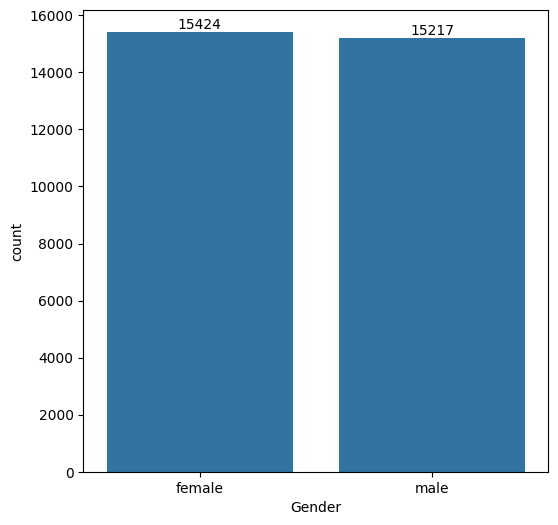

In [ ]:
# gender distribution
plt.figure(figsize=(6,6))
ax=sns.countplot(data=df, x = "Gender")
ax.bar_label(ax.containers[0])
plt.show()

In [ ]:
gb = df.groupby("ParentEduc").agg({"MathScore":'mean', "ReadingScore":"mean", "WritingScore":"mean"})
print(gb)

                    MathScore  ReadingScore  WritingScore
ParentEduc                                               
associate's degree  68.365586     71.124324     70.299099
bachelor's degree   70.466627     73.062020     73.331069
high school         64.435731     67.213997     65.421136
master's degree     72.336134     75.832921     76.356896
some college        66.390472     69.179708     68.501432
some high school    62.584013     65.510785     63.632409


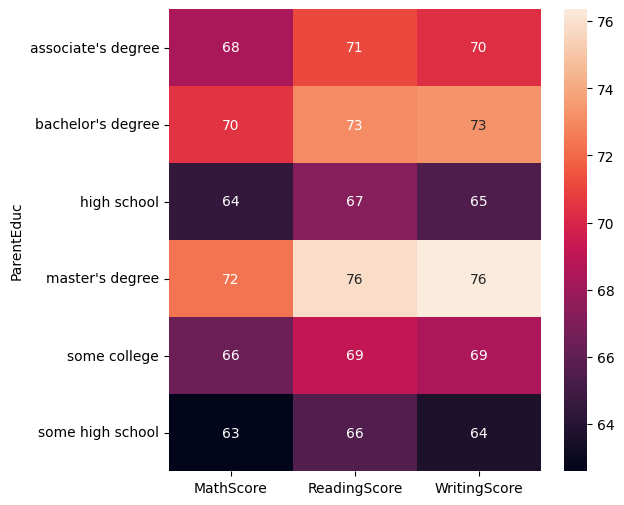

In [ ]:
plt.figure(figsize=(6,6))
sns.heatmap(gb, annot = True)
plt.show()

In [ ]:
gb1 = df.groupby("ParentMaritalStatus").agg({"MathScore":'mean', "ReadingScore":"mean", "WritingScore":"mean"})
print(gb1)

                     MathScore  ReadingScore  WritingScore
ParentMaritalStatus                                       
divorced             66.691197     69.655011     68.799146
married              66.657326     69.389575     68.420981
single               66.165704     69.157250     68.174440
widowed              67.368866     69.651438     68.563452


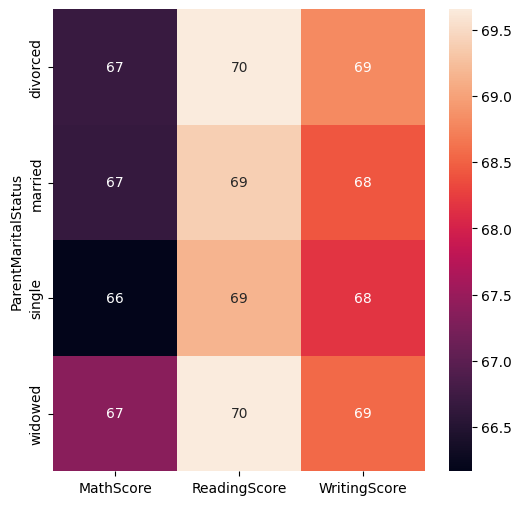

In [ ]:
plt.figure(figsize=(6,6))
sns.heatmap(gb1, annot = True)
plt.show()

/tmp/ipython-input-1712323099.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x="Gender", y="MathScore", estimator='mean', ci=None)


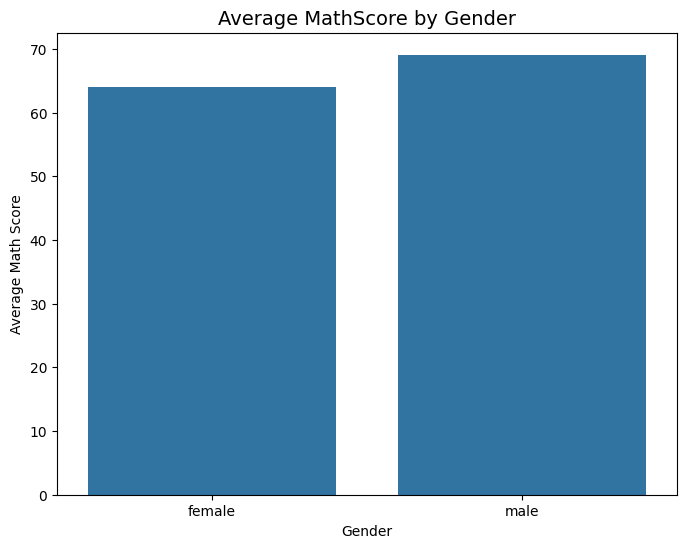

In [ ]:
# Gender vs Average Scores
plt.figure(figsize=(8,6))
sns.barplot(data=df, x="Gender", y="MathScore", estimator='mean', ci=None)
plt.title("Average MathScore by Gender", fontsize=14)
plt.xlabel("Gender")
plt.ylabel("Average Math Score")
plt.show()


/tmp/ipython-input-3400003784.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x="Gender", y="ReadingScore", estimator='mean', ci=None)


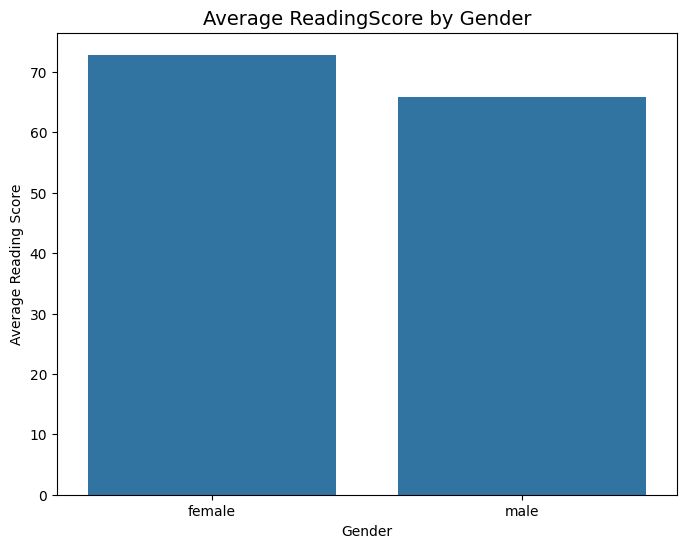

In [ ]:
plt.figure(figsize=(8,6))
sns.barplot(data=df, x="Gender", y="ReadingScore", estimator='mean', ci=None)
plt.title("Average ReadingScore by Gender", fontsize=14)
plt.xlabel("Gender")
plt.ylabel("Average Reading Score")
plt.show()


/tmp/ipython-input-248657323.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x="Gender", y="WritingScore", estimator='mean', ci=None)


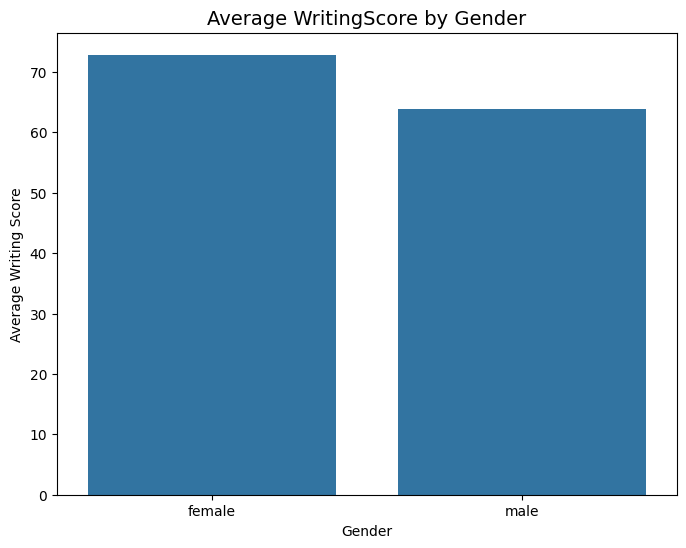

In [ ]:
plt.figure(figsize=(8,6))
sns.barplot(data=df, x="Gender", y="WritingScore", estimator='mean', ci=None)
plt.title("Average WritingScore by Gender", fontsize=14)
plt.xlabel("Gender")
plt.ylabel("Average Writing Score")
plt.show()


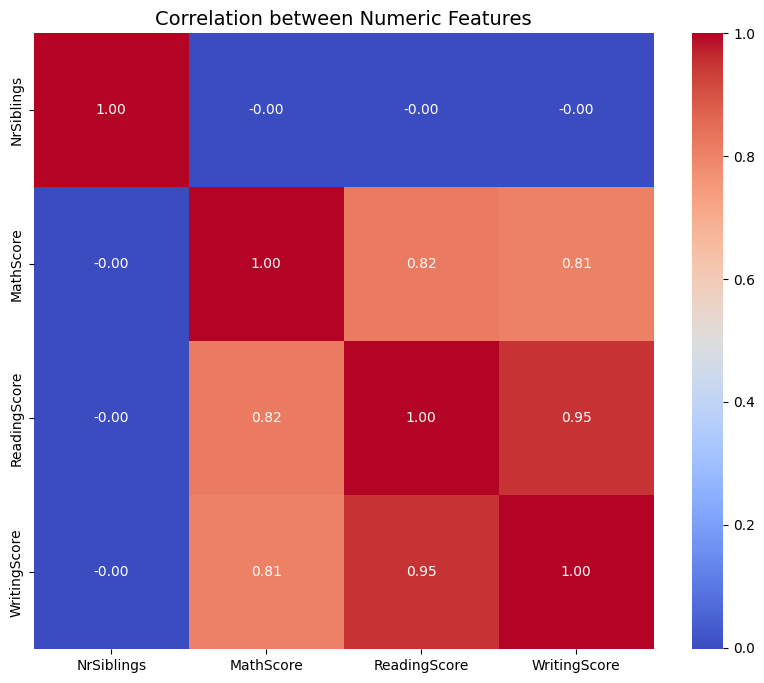

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation between Numeric Features", fontsize=14)
plt.show()


In [ ]:
# CART

from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Preprocessing
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

# One-Hot Encoding for categorical features
df_encoded = pd.get_dummies(df, drop_first=True)

# Features and Targets
X = df_encoded.drop(["MathScore", "ReadingScore", "WritingScore"], axis=1)
y = df_encoded[["MathScore", "ReadingScore", "WritingScore"]]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2. Train CART Model
cart = DecisionTreeRegressor(max_depth=6, random_state=42)
cart.fit(X_train, y_train)

# Predictions
y_pred_cart = cart.predict(X_test)

# 3. Evaluation
def evaluate(y_true, y_pred, model_name):
    print(f"\n{model_name}")
    for i, col in enumerate(y.columns):
        print(f"\n{col}")
        print("R² Score:", r2_score(y_true.iloc[:, i], y_pred[:, i]))
        print("MAE:", mean_absolute_error(y_true.iloc[:, i], y_pred[:, i]))
        print("RMSE:", np.sqrt(mean_squared_error(y_true.iloc[:, i], y_pred[:, i])))

evaluate(y_test, y_pred_cart, "Decision Tree")

# 4. Predicted Values
predicted_values = pd.DataFrame(y_pred_cart, columns=y.columns)
print("\nPredicted Scores:\n", predicted_values)



Decision Tree

MathScore
R² Score: 0.250163107511432
MAE: 10.650786908391698
RMSE: 13.190321748476189

ReadingScore
R² Score: 0.20697257805185398
MAE: 10.567441756071068
RMSE: 13.062206186849277

WritingScore
R² Score: 0.29141693491212095
MAE: 10.462344931101597
RMSE: 12.93683845664152

Predicted Scores:
       MathScore  ReadingScore  WritingScore
0     64.413333     74.273333     75.426667
1     84.023529     77.276471     77.100000
2     70.910560     66.203116     63.810444
3     69.805556     76.972222     74.666667
4     61.460784     62.406863     61.000000
...         ...           ...           ...
6124  54.289398     53.389685     49.186246
6125  85.430233     77.046512     74.441860
6126  60.482587     68.270315     66.139303
6127  70.910560     66.203116     63.810444
6128  67.229244     74.715294     74.695462

[6129 rows x 3 columns]


In [ ]:
# KNN Regression

from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

# Preprocessing
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

df = pd.get_dummies(df, drop_first=True)

# Features & Targets
X = df.drop(["MathScore", "ReadingScore", "WritingScore"], axis=1)
y = df[["MathScore", "ReadingScore", "WritingScore"]]

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# KNN Model
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)

# Predictions
y_pred_knn = knn.predict(X_test)

# Evaluation
print("\nKNN")
for i, col in enumerate(y.columns):
    print(f"\n {col}")
    print("R² Score:", r2_score(y_test.iloc[:, i], y_pred_knn[:, i]))
    print("MAE:", mean_absolute_error(y_test.iloc[:, i], y_pred_knn[:, i]))
    print("RMSE:", np.sqrt(mean_squared_error(y_test.iloc[:, i], y_pred_knn[:, i])))

# Predicted values
predicted_values_knn = pd.DataFrame(y_pred_knn, columns=y.columns)
print("\nPredicted Scores (KNN):\n", predicted_values_knn)



KNN

 MathScore
R² Score: 0.11560552579374628
MAE: 11.545733398596836
RMSE: 14.325012098088326

 ReadingScore
R² Score: 0.0446770783206214
MAE: 11.591678903573175
RMSE: 14.336644997566971

 WritingScore
R² Score: 0.15539772620379322
MAE: 11.37399249469734
RMSE: 14.124038539884047

Predicted Scores (KNN):
       MathScore  ReadingScore  WritingScore
0          72.6          80.0          82.2
1          73.0          64.2          64.0
2          75.8          75.8          71.0
3          60.0          69.4          66.0
4          50.0          55.6          54.0
...         ...           ...           ...
6124       55.8          52.6          48.6
6125       83.2          75.6          71.2
6126       64.0          73.2          69.2
6127       72.2          70.4          66.2
6128       69.0          79.6          78.0

[6129 rows x 3 columns]


In [ ]:
# Random Forest Regression

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

# Preprocessing
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

df = pd.get_dummies(df, drop_first=True)

# Features & Targets
X = df.drop(["MathScore", "ReadingScore", "WritingScore"], axis=1)
y = df[["MathScore", "ReadingScore", "WritingScore"]]

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Random Forest Model
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

# Predictions
y_pred_rf = rf.predict(X_test)

# Evaluation
print("\nRandom Forest")
for i, col in enumerate(y.columns):
    print(f"\n {col}")
    print("R² Score:", r2_score(y_test.iloc[:, i], y_pred_rf[:, i]))
    print("MAE:", mean_absolute_error(y_test.iloc[:, i], y_pred_rf[:, i]))
    print("RMSE:", np.sqrt(mean_squared_error(y_test.iloc[:, i], y_pred_rf[:, i])))

# Predicted values
predicted_values_rf = pd.DataFrame(y_pred_rf, columns=y.columns)
print("\nPredicted Scores (Random Forest):\n", predicted_values_rf)



Random Forest

 MathScore
R² Score: 0.10927985793169881
MAE: 11.568979505569425
RMSE: 14.376150937048314

 ReadingScore
R² Score: 0.03344444682832326
MAE: 11.641257452445066
RMSE: 14.420683409862571

 WritingScore
R² Score: 0.15469648250643708
MAE: 11.37506519344874
RMSE: 14.129900670705759

Predicted Scores (Random Forest):
       MathScore  ReadingScore  WritingScore
0     64.681167     72.665833     74.977917
1     86.792750     79.204917     76.837583
2     76.377381     75.464107     70.567500
3     68.008500     72.335667     67.112000
4     48.835500     53.951917     47.677417
...         ...           ...           ...
6124  60.074591     56.755772     51.843425
6125  87.253964     80.047643     72.944429
6126  65.252321     73.931560     70.823690
6127  77.890266     68.743478     68.264377
6128  68.305182     78.579043     77.666654

[6129 rows x 3 columns]


In [ ]:
# --- COMPARISON
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

model_scores = {}

def evaluate_model(name, y_true, y_pred):
    scores = {"R2": [], "MAE": [], "RMSE": []}

    for i, col in enumerate(y_true.columns):
        r2  = r2_score(y_true.iloc[:, i], y_pred[:, i])
        mae = mean_absolute_error(y_true.iloc[:, i], y_pred[:, i])
        rmse = np.sqrt(mean_squared_error(y_true.iloc[:, i], y_pred[:, i]))

        scores["R2"].append(r2)
        scores["MAE"].append(mae)
        scores["RMSE"].append(rmse)

    # Average scores
    avg_r2   = np.mean(scores["R2"])
    avg_mae  = np.mean(scores["MAE"])
    avg_rmse = np.mean(scores["RMSE"])

    model_scores[name] = {
        "Avg_R2": avg_r2,
        "Avg_MAE": avg_mae,
        "Avg_RMSE": avg_rmse
    }

    print(f"\n {name} Scores:")
    print(f"Average R²:   {avg_r2:.4f}")
    print(f"Average MAE:  {avg_mae:.4f}")
    print(f"Average RMSE: {avg_rmse:.4f}")


# ---- Evaluate all three models ----
evaluate_model("CART", y_test, y_pred_cart)
evaluate_model("KNN", y_test, y_pred_knn)
evaluate_model("Random Forest", y_test, y_pred_rf)

# -------- Find Best Model --------
best_model = max(model_scores, key=lambda m: model_scores[m]["Avg_R2"])

print("\n\nBEST MODEL BASED ON AVERAGE R²:",best_model)


 CART Scores:
Average R²:   0.2495
Average MAE:  10.5602
Average RMSE: 13.0631

 KNN Scores:
Average R²:   0.1052
Average MAE:  11.5038
Average RMSE: 14.2619

 Random Forest Scores:
Average R²:   0.0991
Average MAE:  11.5284
Average RMSE: 14.3089


BEST MODEL BASED ON AVERAGE R²: CART


In [ ]:
from sklearn.tree import DecisionTreeRegressor

# Separate models for each subject
models = {
    "MathScore": DecisionTreeRegressor(max_depth=6, random_state=42),
    "ReadingScore": DecisionTreeRegressor(max_depth=6, random_state=42),
    "WritingScore": DecisionTreeRegressor(max_depth=6, random_state=42)
}

# Train all models
for target in models:
    models[target].fit(X_train, y_train[target])


In [ ]:
pip install shap



 SHAP for CART



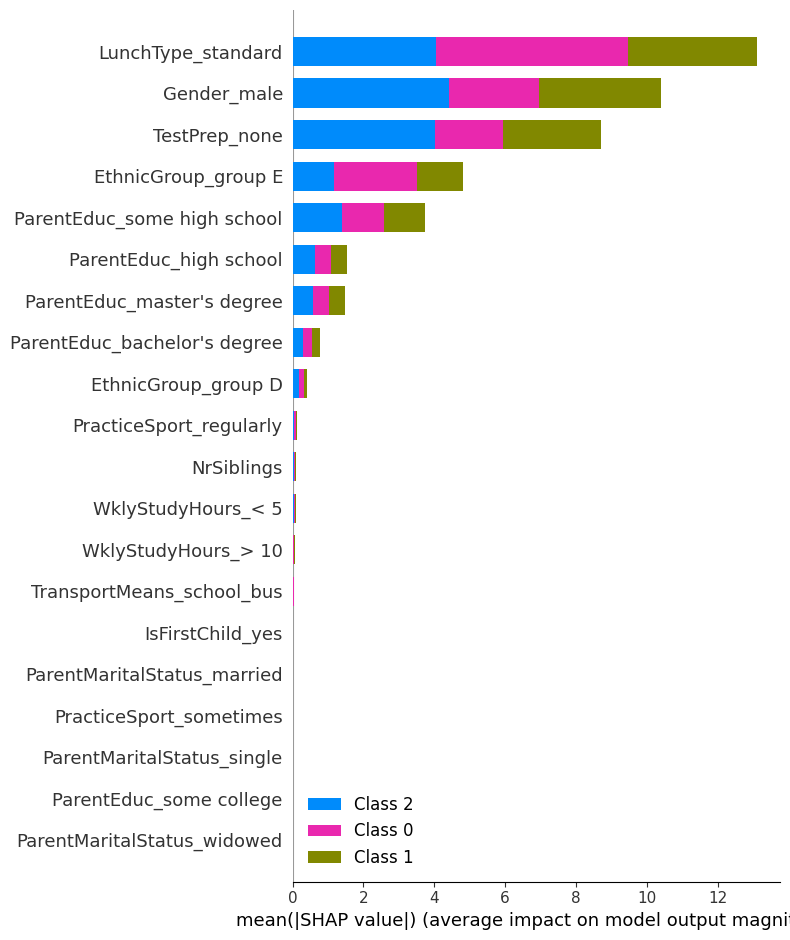

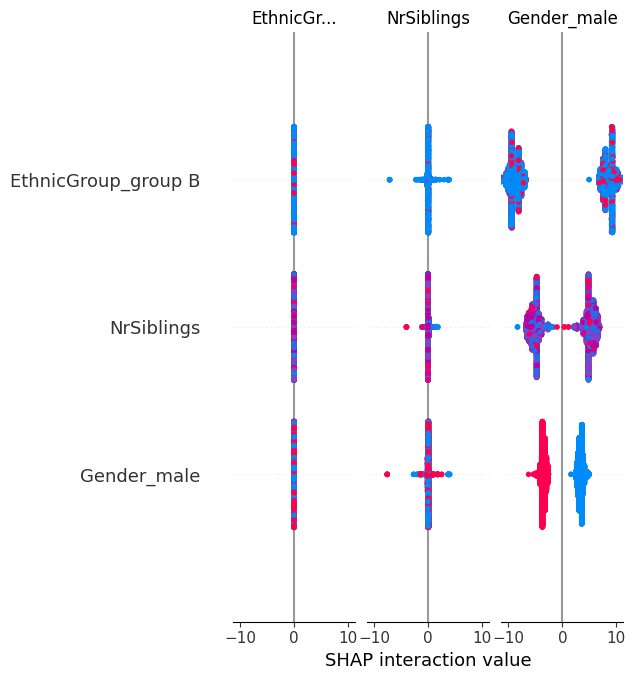


 SHAP for Random Forest



In [ ]:
import shap

models = {
    "CART": cart,
    "Random Forest": rf
}

shap_explainers = {}
shap_values_all = {}

for target in models:
    print(f"\n SHAP for {target}\n")

    model = models[target]

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)

    shap_explainers[target] = explainer
    shap_values_all[target] = shap_values

    # Summary Bar Plot (global importance)
    shap.summary_plot(shap_values, X_test, plot_type="bar", show=True)

    # Full Summary Plot (direction of effect)
    shap.summary_plot(shap_values, X_test, show=True)
